In [101]:
import pandas as pd
import numpy as np
import json
from torch.utils.data import Dataset
from PIL import Image
import os
from torchvision import transforms
import torch

In [102]:
# Config
PATH = r'H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/'

BATCH_SIZE = 10

In [103]:
with open(r"H:\Documents\Ing 3\PFE\data\Data_Projet\data_propre.json", 'r') as f:
    data = json.load(f)



In [104]:
df = pd.DataFrame(data)

print(df.head())

          id  epine
0  P03327766      1
1  P04681621      0
2  P03550384      0
3  P01902590      0
4  P02520870      1


In [105]:
print(f"nb ocurence épine {df['epine'].value_counts()}")

nb ocurence épine epine
 1    1169
 0    1108
-1       1
Name: count, dtype: int64


In [106]:
test = df['epine'] == -1
print(df[test])

             id  epine
1647  P04066423     -1


In [107]:
# Construction du chemin complet de la même manière que dans le lambda
full_path = "H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000\P0009035.jpg"

# Utilisation directe de la fonction
file_exists = os.path.exists(full_path)

print(f"Le chemin complet testé est : {full_path}")
print(f"Le fichier existe-t-il ? {file_exists}")

Le chemin complet testé est : H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000\P0009035.jpg
Le fichier existe-t-il ? True


In [108]:
import os
import pandas as pd

# Supposons que 'original_df' est ton DataFrame initial
# et 'PATH' est le répertoire racine des images.
# PATH = '/chemin/vers/tes/images/' 

def filter_missing_images(df, path_prefix):
    """
    grrr Filtre le DataFrame en ne gardant que les lignes 
    dont le fichier image existe sur le disque.
    """
    print(f"Taille du DataFrame avant filtrage: {len(df)}")
    
    # 1. Crée le chemin complet pour chaque image
    df['full_path'] = path_prefix + df['id'] +".jpg"
    print(df['full_path'].value_counts())
    print(df.head())
    # 2. Vérifie l'existence du fichier
    df['exists'] = df['full_path'].apply(lambda x: os.path.exists(x))
    
    # 3. Filtre et crée le nouveau DataFrame
    filtered_df = df[df['exists']].reset_index(drop=True)
    
    # Affichage du résultat
    missing_count = len(df) - len(filtered_df)
    print(f"Images manquantes trouvées et retirées: {missing_count}")
    print(f"Taille du DataFrame après filtrage: {len(filtered_df)}")
    
    # Optionnel: Tu peux supprimer les colonnes temporaires si tu ne veux pas les garder
    return filtered_df.drop(columns=['full_path', 'exists'])

# --- Utilisation ---
cleaned_df = filter_missing_images(df, PATH)
print(f"nb ocurence épine {cleaned_df['epine'].value_counts()}")

Taille du DataFrame avant filtrage: 2278
full_path
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P03327766.jpg    1
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P05238024.jpg    1
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P04155235.jpg    1
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P05257476.jpg    1
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P05237567.jpg    1
                                                                                          ..
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P03211283.jpg    1
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P02947061.jpg    1
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/LY0213980.jpg    1
H:\Documents\Ing 3\PFE\data\Data_Projet\mission_herbonaute_2000_seg_black/P05257656.jpg    1
H:\Documents\Ing 3\

In [109]:
import torch
from torch.utils.data import Dataset
from PIL import Image


class EpineDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_path = self.df.iloc[idx]['id']
        label = self.df.iloc[idx]['epine']
        image_id = img_path
        img_path = PATH+img_path+".jpg"
        img = Image.open(img_path).convert('RGB')
        original_shape = img.size  # (Width, Height)
        im0_shape = torch.tensor([original_shape[1], original_shape[0]], dtype=torch.int)  # (H, W)

        if self.transform is not None:
            img = self.transform(img)

        label_tensor = torch.tensor(label, dtype=torch.long)

        metadata_dict = {
            'id': image_id,
            'label': label_tensor,
            'original_shape': im0_shape,
        }

        return img, metadata_dict

In [110]:
from torchvision import transforms

IMAGE_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

img_size = 640
# Utilisez transforms.Compose pour enchaîner les transformations standard.
transform = transforms.Compose([
    # 1. Convertit l'image PIL en tenseur (C, H, W) et la met entre 0 et 1.
    # C'est la fonction standard de torchvision pour le faire.
    transforms.ToTensor(),

    # 2. Redimensionne l'image.
    # Note: L'argument 'antialias=True' est pris en charge dans les versions récentes
    # de torchvision (>= 0.13), ce qui équivaut souvent à la fonctionnalité de v2.
    transforms.Resize((img_size, img_size), antialias=True),

    # Optionnel: Si vous avez besoin de normaliser l'image APRÈS la conversion et
    # le redimensionnement, vous ajouteriez ceci (bien que YOLO vienne souvent
    # avec sa propre normalisation/préparation):
    # transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

In [111]:
## Dataloader

In [112]:
from torch.utils.data import Subset

dataset = EpineDataset(cleaned_df, transform=transform)

print(len(dataset))


subset = Subset(dataset, range(10))
print(len(subset))

898
10


In [113]:
from torch.utils.data import DataLoader

# train_size = int(0.8 * len(dataset))
# val_size = len(dataset) - train_size
# train_dataset, val_dataset = torch.utils.data.random_split(
#     dataset, [train_size, val_size]
# )
# 
# train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
# 
# val_loader = DataLoader(val_dataset,
#                         batch_size=BATCH_SIZE)

loader = DataLoader(subset, batch_size=1, shuffle=True)

In [129]:
from YOLOv7_ag.models.experimental import attempt_load
from YOLOv7_ag.utils.general import non_max_suppression, scale_coords
from YOLOv7_ag.utils.torch_utils import select_device
from YOLOv7_ag.runs.train import *
from tqdm import tqdm

def run_to_csv(loader, model, tresh, device='cpu'):
    model = attempt_load(model, map_location=device)
    model.eval()
    detections = []
    total_batches = len(loader) if hasattr(loader, '__len__') else None
    with torch.no_grad():
        for img, metadata_dict in tqdm(loader, desc="Inférence sur les images", total=total_batches):
            predictions = model(img)[0]
            preditions_list = non_max_suppression(predictions) # iou_thres=tresh)
            for i, det in enumerate(preditions_list):
                img_id = metadata_dict["id"][i]
                im0_shape = metadata_dict["original_shape"][i]
                if len(det):
                    det[:, :4] = scale_coords(img.shape[2:], det[:, :4], im0_shape)
                    
                    # 2. Convertissez en entier lors de l'ajout à la liste (ce qui fait l'arrondi/troncation)
                    # Cela se fait déjà avec .item(), que vous pouvez encadrer d'un int() pour plus de sûreté.
                    
                    for *xyxy, conf, cls in det:
                        detections.append({
                            'image_id': img_id,
                            'x_min': int(xyxy[0].item()), # Force l'entier ici
                            'y_min': int(xyxy[1].item()),
                            'x_max': int(xyxy[2].item()),
                            'y_max': int(xyxy[3].item()),
                            'confidence': conf.item(),
                            'class_id': cls.item()
                        })
    return pd.DataFrame(detections)

test = run_to_csv(loader, 'runs/train/yolov7-ag/weights/best.pt', 0.5)   

        

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
IDetect.fuse


Inférence sur les images: 100%|██████████| 10/10 [00:25<00:00,  2.60s/it]


In [143]:
print(test.head())
print(test.value_counts('image_id'))

    image_id  x_min  y_min  x_max  y_max  confidence  class_id
0  NCY014503   1821   4637   3837   6618    0.971074       0.0
1  NCY014503   4374   5865   6659   7949    0.960953       0.0
2  NCY014503   2354   3164   4530   5393    0.958983       0.0
3  NCY014503   3089   1751   5823   4311    0.957382       0.0
4  NCY014503   6111   2222   7326   4177    0.955139       0.0
image_id
MPU1166167    32
P01902590     32
P00412460     27
MPU695893     26
LY0272200     25
NCY014503     21
P02742188     21
P02520870     14
P02938082     12
LY0237730      7
Name: count, dtype: int64


In [131]:
from PIL import Image

def crop_detection(df_row, image_path_col='image_id'):


    image_id = df_row[image_path_col]
    x_min = int(df_row['x_min'])
    y_min = int(df_row['y_min'])
    x_max = int(df_row['x_max'])
    y_max = int(df_row['y_max'])
    
    print(x_min, x_max, y_min, y_max)
    
    image_path = PATH+image_id +".jpg"
    
    try:
        original_image = Image.open(image_path)
    except FileNotFoundError:
        print(f"Le fichier image n'a pas été trouvé à : {image_path}")
        return None
    
    print(f"original image size {original_image.size}")
    cropped_image = original_image.crop((x_min, y_min, x_max, y_max))
    
    return cropped_image

In [137]:
crop_detection(test.iloc[1]).show()

4374 6659 5865 7949
original image size (7326, 10161)


In [138]:
import cv2
def draw_boxes_on_image(df_detections, image_id, path_to_images=PATH):
    """
    Charge une image et dessine toutes les bounding boxes qui lui sont associées.

    Args:
        df_detections (pd.DataFrame): Le DataFrame 'test' contenant toutes les détections.
        image_id (str): L'identifiant unique de l'image (ex: 'image_test_01').
        path_to_images (str): Le chemin du répertoire où se trouvent les images originales.
    """
    
    # 1. Filtrer les détections pour l'image spécifique
    image_detections = df_detections[df_detections['image_id'] == image_id].copy()
    
    if image_detections.empty:
        print(f"Grrr! Aucune détection trouvée pour l'image ID: {image_id}")
        return None

    # 2. Construire le chemin et charger l'image
    image_path = path_to_images + image_id + ".jpg"
    
    # OpenCV charge les images en format BGR
    img = cv2.imread(image_path) 
    
    if img is None:
        print(f"Grrr! Impossible de charger l'image à : {image_path}")
        return None

    # 3. Dessiner chaque boîte
    for index, row in image_detections.iterrows():
        # Coordonnées (doivent être des entiers)
        x_min, y_min, x_max, y_max = map(int, [row['x_min'], row['y_min'], row['x_max'], row['y_max']])
        confidence = row['confidence']
        class_id = int(row['class_id'])

        # Définir la couleur et le texte
        color = (0, 255, 0)  # Vert en BGR
        label = f"Classe {class_id}: {confidence:.2f}"
        
        # Dessiner le rectangle (P1, P2 sont les coins opposés, couleur, épaisseur)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
        
        # Dessiner le fond pour le texte
        cv2.rectangle(img, (x_min, y_min - 25), (x_min + len(label) * 15, y_min), color, -1)
        
        # Écrire le texte (image, texte, position, police, taille, couleur, épaisseur)
        cv2.putText(img, label, (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    # 4. Afficher l'image (pour Jupyter/Google Colab, vous pourriez avoir besoin de cv2.imshow())
    # Attention: cv2.imshow() peut ne pas fonctionner dans certains environnements
    cv2.imwrite(f"detections_{image_id}.jpg", img)
    print(f"Grrr! Image avec détections sauvegardée sous detections_{image_id}.jpg")
    
    # Vous pouvez retourner l'image si vous voulez l'utiliser après
    return img

Grrr! Image avec détections sauvegardée sous detections_NCY014503.jpg


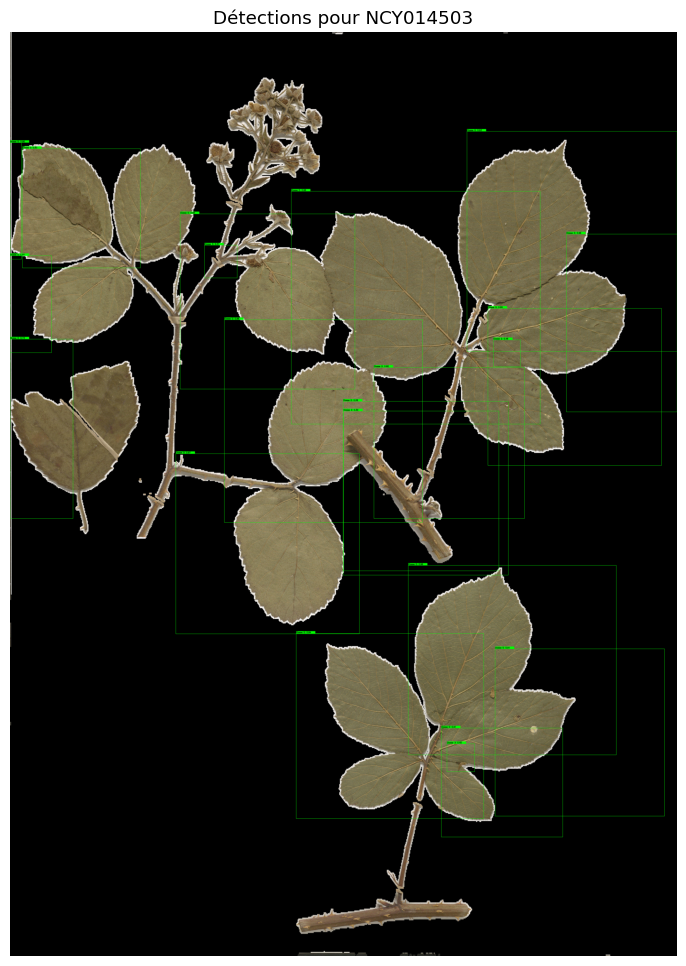

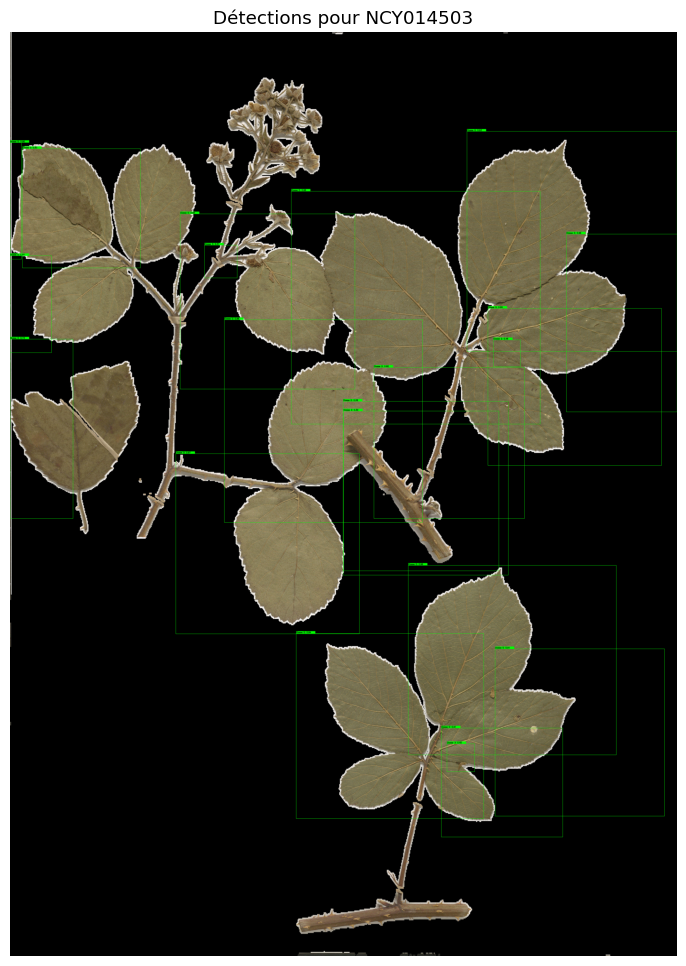

In [142]:
image_a_visualiser = 'NCY014503'
%matplotlib inline
# Grrr, exécution de la fonction :
image_resultat = draw_boxes_on_image(test, image_a_visualiser)

# Si vous êtes dans un environnement qui supporte Matplotlib (Jupyter, Colab)
# vous pouvez utiliser ceci pour l'affichage in-line :
from matplotlib import pyplot as plt
if image_resultat is not None:
    # OpenCV est BGR, Matplotlib attend RGB, donc conversion
    img_rgb = cv2.cvtColor(image_resultat, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 12))
    plt.imshow(img_rgb)
    plt.title(f"Détections pour {image_a_visualiser}")
    plt.axis('off')
    plt.show()